<a href="https://colab.research.google.com/github/AlvaroAceval16/MachineLearning/blob/main/P4_Random_Forest_Regresion_Automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Cargar el dataset

#ID del archivo
from google.colab import drive
drive.mount('/content/drive')

# https://drive.google.com/file/d/1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf/view?usp=drive_link
file_id = '1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf'

#URL de descarga directa
url = f'https://drive.google.com/uc?id={file_id}'

#Leer el archivo CSV directamente desde la URL
df = pd.read_csv(url)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
# 2. Definir variables predictoras y variable objetivo
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']
# 3. Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# 4. Entrenar modelo Random Forest

# Convert relevant columns in X_train and X_test to numeric, coercing errors to NaN
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Convert y_train and y_test to numeric, coercing errors to NaN
y_train = pd.to_numeric(y_train, errors='coerce')
y_test = pd.to_numeric(y_test, errors='coerce')

# Combine X and y for dropping rows with NaN in a consistent way
train_data = pd.concat([X_train, y_train], axis=1)
train_data = train_data.dropna()

X_train = train_data.drop(columns=['price'])
y_train = train_data['price']

test_data = pd.concat([X_test, y_test], axis=1)
test_data = test_data.dropna()

X_test = test_data.drop(columns=['price'])
y_test = test_data['price']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# 5. Evaluar el modelo
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Coeficiente de determinación (R²): {r2_rf:.2f}")
import numpy as np
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse_rf)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 3277092.07
Coeficiente de determinación (R²): 0.96
Raíz del Error cuadrático medio (RMSE): 1810.27


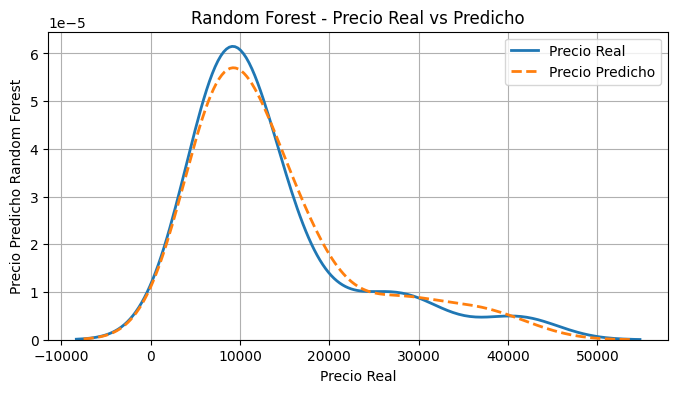

In [9]:
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()


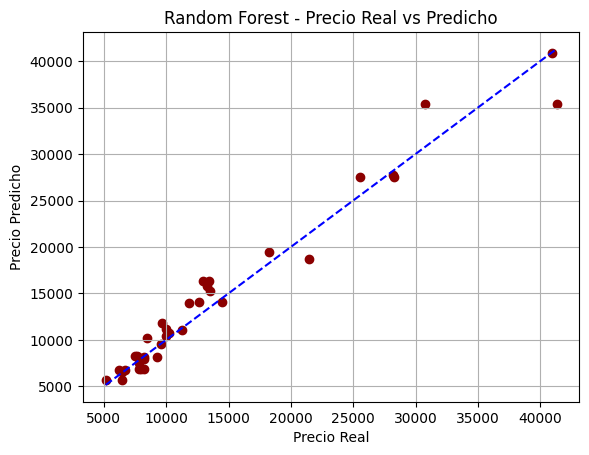

In [10]:
#Comparar precios con diagrama de dispersión
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [11]:
#Modelo con parámetros ajustados
rf_model = RandomForestRegressor(
n_estimators=200, # más árboles
max_depth=8, # limitar profundidad
min_samples_split=4, # evitar divisiones con pocos datos
min_samples_leaf=3, # cada hoja al menos con 3 observaciones
max_features='sqrt', # usa raíz cuadrada del total de features
random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

MSE: 5553592.75
R²: 0.93
RMSE: 2356.61


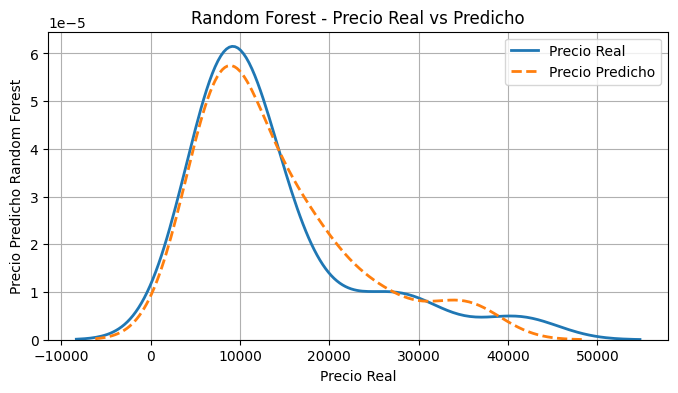

In [12]:
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()


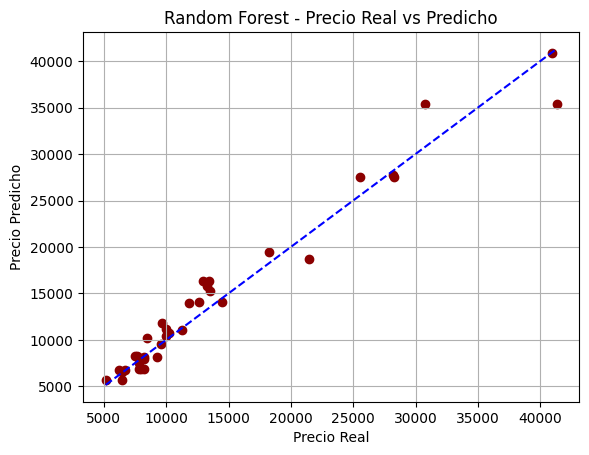

In [13]:
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [4, 6, 8, None],
'min_samples_split': [2, 4, 6],
'min_samples_leaf': [1, 2, 3],
'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
RandomForestRegressor(random_state=42),
param_grid,
cv=3, # validación cruzada
scoring='r2',
n_jobs=-1,
verbose=2
)

grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R²:", grid_search.best_score_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Mejores parámetros: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 300}
Mejor R²: 0.8649960074618198


MSE: 3869791.02
R²: 0.95
RMSE: 1967.18


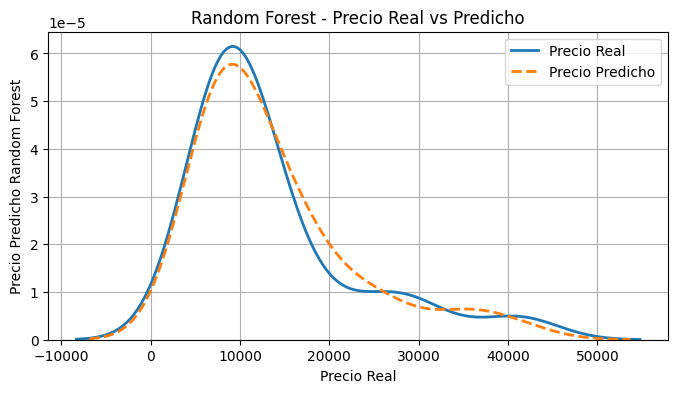

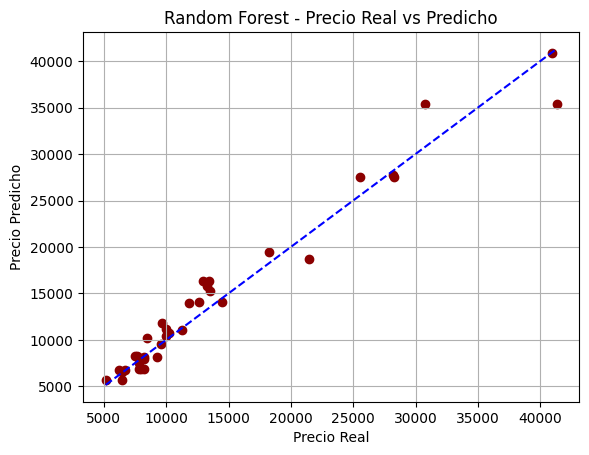

In [15]:
# Modelo con parámetros ajustados
rf_model = RandomForestRegressor(
n_estimators=300, # más árboles
max_depth=8, # limitar profundidad
min_samples_split=2, # evitar divisiones con pocos datos
min_samples_leaf=1, # cada hoja al menos con 1 observaciones
max_features='sqrt', # usa raíz cuadrada del total de features
random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()